# VAETIMEGAN WTI

In [9]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import tensorflow as tf
from tensorflow.keras import backend as K

#!git clone https://github.com/Meowth239/dse4101-project.git
#!git -C /content/dse4101-project checkout LSTM_r
#import sys
#sys.path.append('/content/dse4101-project/lstm_src')

import my_lstm
importlib.reload(my_lstm)
import gc

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast

In [10]:
df = pd.read_csv('../data/final_data_with_VAETIMEGAN.csv')
#df = pd.read_csv('/content/dse4101-project/data/final_data_with_VAETIMEGAN.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1958-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.005484,-0.073454,0.013188,0.008006,-0.203766
1,1958-04-01,0.020833,-0.009353,0.060724,0.005213,-0.003673,-0.079281,0.011769,0.009704,0.018075
2,1958-05-01,0.006006,-0.008792,0.009556,0.067115,0.002756,0.014742,0.017015,0.010501,0.180503
3,1958-06-01,-0.054147,0.010266,-0.037406,0.144931,0.003663,0.009709,0.013104,0.007785,-0.135577
4,1958-07-01,-0.090823,-0.006553,-0.026149,0.010176,0.000914,-0.063144,0.014577,0.008258,-0.147348


In [11]:
feature_cols = [
    "wti_ret"
]

target_col = "wti_ret"

In [12]:
df = df.sort_values("Date").reset_index(drop=True)

# compute indices based on original evaluation and test split
train_size = df.index[df["Date"] < "2014-02-01"][-1] + 1
val_end = df.index[df["Date"] <= "2020-01-01"][-1] + 1

# split using iloc
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 671
Validation data length: 72
Test data length: 72


In [ ]:
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
}

param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []
failed_combos = []

max_retries = 2

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    success = False

    for attempt in range(1, max_retries + 1):
        try:
            print(f"Attempt {attempt}/{max_retries}")

            # clear memory before each attempt
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

            val_forecasts = expanding_window_lstm_forecast(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            initial_train_size=train_size,
            end_idx=val_end,
            date_col="Date",
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
            )

            if len(val_forecasts) == 0:
                print("No forecasts generated.")
                raise ValueError("No forecasts generated")

            mse = mean_squared_error(
                val_forecasts["actual"],
                val_forecasts["predicted"]
            )

            print(f"Validation MSE: {mse:.6f}")

            results_grid.append({
                "lookback": lb,
                "dropout": dr,
                "units": units,
                "epochs": ep,
                "mse": mse,
                "attempt_used": attempt
            })

            success = True
            break

        except Exception as e:
            print(f"Error on attempt {attempt}: {e}")

            # clear memory after failure
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

    if not success:
        print("Failed after all retries. Skipping this combination.")
        failed_combos.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep
        })

# --------------------------------------------------
# results
# --------------------------------------------------

results_grid_df = pd.DataFrame(results_grid).sort_values("mse").reset_index(drop=True)
failed_combos_df = pd.DataFrame(failed_combos)

In [ ]:
results_grid

In [11]:


# =========================================================
# completed results from colab
# =========================================================
results_grid = [
    {'lookback': 2, 'dropout': 0.001, 'units': 50, 'epochs': 50, 'mse': 0.08703139957276582, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 50, 'epochs': 100, 'mse': 0.0926430972724055, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 170, 'epochs': 50, 'mse': 0.07934547800064226, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 170, 'epochs': 100, 'mse': 0.07970318571584396, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 50, 'epochs': 50, 'mse': 0.08908143495317353, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 50, 'epochs': 100, 'mse': 0.08908143495317353, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 170, 'epochs': 50, 'mse': 0.0849222911937075, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 170, 'epochs': 100, 'mse': 0.0849222911937075, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.001, 'units': 50, 'epochs': 50, 'mse': 0.18189690131237327, 'attempt_used': 1}
]

# if you already have previous failures, paste them here
failed_combos = []

# =========================================================
# 2. Full parameter grid
# =========================================================
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
}

param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

# =========================================================
# 3. Done combinations
# =========================================================
results_grid_df = pd.DataFrame(results_grid)

done_combos = set(zip(
    results_grid_df["lookback"],
    results_grid_df["dropout"],
    results_grid_df["units"],
    results_grid_df["epochs"]
))

remaining_combos = [combo for combo in param_combinations if combo not in done_combos]

print("Total combinations:", len(param_combinations))
print("Completed combinations:", len(done_combos))
print("Remaining combinations:", len(remaining_combos))
print("\nRemaining combos:")
for combo in remaining_combos:
    print(combo)

results_path = "results/results_grid_resumed.csv"
failed_path = "results/failed_combos_resumed.csv"

# save current status immediately
pd.DataFrame(results_grid).to_csv(results_path, index=False)
pd.DataFrame(failed_combos).to_csv(failed_path, index=False)

print(f"\nInitial progress saved to: {results_path}")
print(f"Initial failed log saved to: {failed_path}")

# =========================================================
# 5. Resume the grid search
# =========================================================
max_tries = 2

for i, (lb, dr, units, ep) in enumerate(remaining_combos, 1):
    print("\n" + "=" * 60)
    print(f"[{i}/{len(remaining_combos)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    success = False

    for attempt in range(1, max_tries + 1):
        print(f"Attempt {attempt}/{max_tries}")

        try:
            # cleanup before each attempt
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

            val_forecasts = expanding_window_lstm_forecast(
                df=df,
                feature_cols=feature_cols,
                target_col=target_col,
                initial_train_size=train_size,
                end_idx=val_end,
                date_col="Date",  
                lookback=lb,
                units=units,
                dropout=dr,
                epochs=ep
            )

            # if val_forecasts is empty, raise error
            if val_forecasts is None or len(val_forecasts) == 0:
                raise ValueError("val_forecasts is empty")

            if not isinstance(val_forecasts, pd.DataFrame):
                val_forecasts = pd.DataFrame(val_forecasts)

            mse = mean_squared_error(
                val_forecasts["actual"],
                val_forecasts["predicted"]
            )

            result_row = {
                "lookback": lb,
                "dropout": dr,
                "units": units,
                "epochs": ep,
                "mse": mse,
                "attempt_used": attempt
            }

            results_grid.append(result_row)

            # save immediately after success
            pd.DataFrame(results_grid).to_csv(results_path, index=False)
            pd.DataFrame(failed_combos).to_csv(failed_path, index=False)

            print(f"Validation MSE: {mse:.10f}")
            print("Saved progress.")

            success = True
            break

        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")

            if attempt == max_tries:
                failed_row = {
                    "lookback": lb,
                    "dropout": dr,
                    "units": units,
                    "epochs": ep,
                    "error": str(e),
                    "attempts_used": attempt
                }
                failed_combos.append(failed_row)

                # save immediately after failure
                pd.DataFrame(results_grid).to_csv(results_path, index=False)
                pd.DataFrame(failed_combos).to_csv(failed_path, index=False)

                print("Logged failure and saved progress.")

    if not success:
        print("Moving to next combination...")

# =========================================================
# 6. Final summary
# =========================================================
print("\n" + "=" * 60)
print("GRID SEARCH RESUME COMPLETE")

final_results_df = pd.DataFrame(results_grid)
final_results_df = final_results_df.sort_values("mse").reset_index(drop=True)

print("\nFinal results:")
print(final_results_df)

if len(final_results_df) > 0:
    best_params = final_results_df.iloc[0]
    print("\nBest parameters found:")
    print(best_params)

print(f"\nFinal results saved to: {results_path}")
print(f"Final failed combos saved to: {failed_path}")

Validation MSE: 0.9318045762
Saved progress.

GRID SEARCH RESUME COMPLETE

Final results:
    lookback  dropout  units  epochs       mse  attempt_used
0          2    0.001    170      50  0.079345             1
1          2    0.001    170     100  0.079703             1
2          2    0.100    170      50  0.084922             1
3          2    0.100    170     100  0.084922             1
4          2    0.001     50      50  0.087031             1
5          2    0.100     50      50  0.089081             1
6          2    0.100     50     100  0.089081             1
7          2    0.001     50     100  0.092643             1
8         10    0.100     50     100  0.135651             1
9         10    0.100     50      50  0.161963             1
10        10    0.001     50      50  0.181897             1
11        10    0.001     50     100  0.478090             2
12        10    0.100    170      50  0.610020             1
13        10    0.001    170      50  0.676471          

In [13]:

results_grid_df = pd.DataFrame(results_grid)
results_grid_df = results_grid_df.sort_values("mse").reset_index(drop=True)

print("\nTop results:")
print(results_grid_df)

print("\nFailed combinations:")
failed_combos_df = pd.DataFrame(failed_combos)
print(failed_combos_df)

# extract best
best_params = results_grid_df.iloc[0]

best_lb = int(best_params["lookback"])
best_dr = float(best_params["dropout"])
best_units = int(best_params["units"])
best_ep = int(best_params["epochs"])

print("\nBest parameters:")
print(best_params)


Top results:
    lookback  dropout  units  epochs       mse  attempt_used
0          2    0.001    170      50  0.079345             1
1          2    0.001    170     100  0.079703             1
2          2    0.100    170      50  0.084922             1
3          2    0.100    170     100  0.084922             1
4          2    0.001     50      50  0.087031             1
5          2    0.100     50      50  0.089081             1
6          2    0.100     50     100  0.089081             1
7          2    0.001     50     100  0.092643             1
8         10    0.100     50     100  0.135651             1
9         10    0.100     50      50  0.161963             1
10        10    0.001     50      50  0.181897             1
11        10    0.001     50     100  0.478090             2
12        10    0.100    170      50  0.610020             1
13        10    0.001    170      50  0.676471             1
14        10    0.100    170     100  0.931805             2
15        

In [14]:
# best parameters from validation
#best_params = {}
#best_params["lookback"] = 2.0
#best_params["dropout"] = 0.001
#best_params["units"] = 170.0
#best_params["epochs"] = 50.0

# comment out if already tuned and just want to run test evaluation with best params


test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,
    end_idx=len(df),
    date_col="Date",
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


Test MSE: 0.4090079734576663
Test MAPE: 6.193641501736179
Test R²: -20.58579693036116


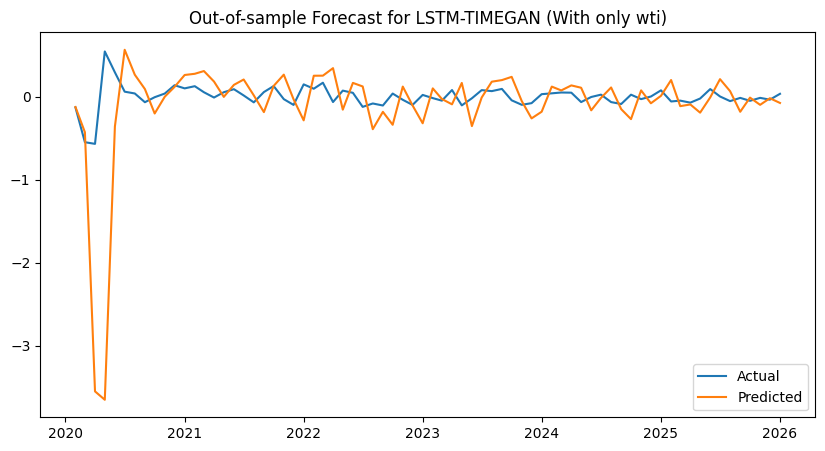

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM-TIMEGAN (With only wti)")
plt.show()

In [16]:
# save results to csv
test_results.to_csv('results/lstm_test_vaetimegan_results.csv', index = False)
